In [23]:
from google.colab import files

uploaded = files.upload()


Saving diabetes.csv to diabetes (1).csv


In [3]:
import pandas as pd

data = pd.read_csv('diabetes.csv')

print("Dataset shape:", data.shape)

data.head()

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [4]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB
None


In [5]:
print(data.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [6]:
X = data.drop('Outcome', axis=1)
y = data['Outcome']

print("Input shape:", X.shape)
print("Output shape:", y.shape)

Input shape: (768, 8)
Output shape: (768,)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (614, 8)
Testing data: (154, 8)


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(64, activation='relu',
                input_shape=(X_train.shape[1],)))

model.add(Dense(64, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,801 (18.75 KB)

 Trainable params: 4,801 (18.75 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [15]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6775 - loss: 0.6177
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7769 - loss: 0.4803
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7964 - loss: 0.4306
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8078 - loss: 0.4102
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8062 - loss: 0.3970
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8192 - loss: 0.3868 
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8274 - loss: 0.3740 
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8388 - loss: 0.3646
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8518 - loss: 0.3529 
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8550 - loss: 0.3449 
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8550 - loss: 0.3362 
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accu

In [16]:
loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)
print("Test Accuracy (%):", accuracy * 100)

Test Loss: 0.7698207497596741
Test Accuracy: 0.8116883039474487
Test Accuracy (%): 81.16883039474487


In [17]:
loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)
print("Test Accuracy (%):", accuracy * 100)

Test Loss: 0.7698207497596741
Test Accuracy: 0.8116883039474487
Test Accuracy (%): 81.16883039474487


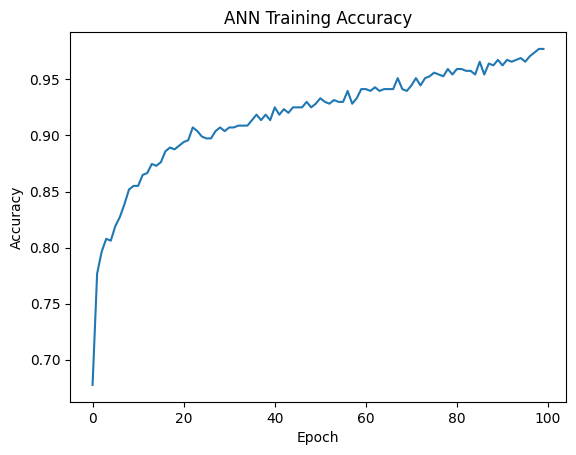

In [18]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])

plt.title('ANN Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.show()

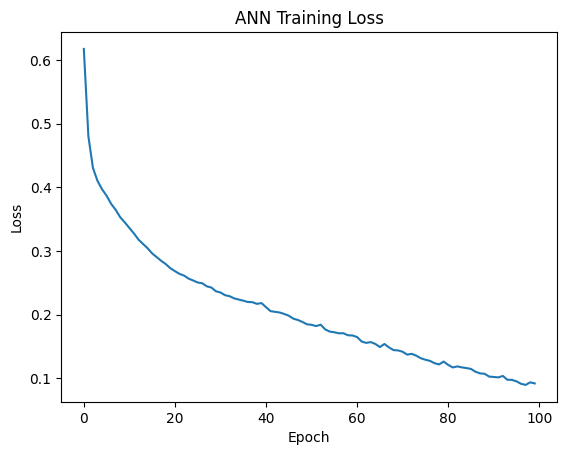

In [19]:
plt.plot(history.history['loss'])

plt.title('ANN Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()

In [20]:
new_data = pd.DataFrame(
    [[8, 183, 64, 0, 0, 23.3, 0.672, 32]],
    columns=X.columns
)

new_data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,8,183,64,0,0,23.3,0.672,32


In [21]:
new_data_scaled = scaler.transform(new_data)

prediction = model.predict(new_data_scaled)

probability = prediction[0][0]

print("Prediction probability:", probability)
print("Probability (%):", probability * 100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
Prediction probability: 1.0
Probability (%): 100.0


In [22]:
if probability >= 0.5:
    print("Final Prediction: Diabetic")
else:
    print("Final Prediction: Non-Diabetic")

Final Prediction: Diabetic
